In [1]:
!pip install yfinance xgboost lightgbm optuna scikit-learn pandas numpy matplotlib shap --quiet

In [2]:
import pandas as pd
import numpy as np
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('lightgbm').setLevel(logging.ERROR)

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, max_error, accuracy_score
)

plt.style.use('dark_background')
DARK, PANEL, BORDER = '#0d1117', '#161b22', '#30363d'
MUTED, BLUE, RED    = '#8b949e', '#58a6ff', '#f87171'
GREEN, YELLOW, PURPLE = '#34d399', '#fbbf24', '#a78bfa'

def sax(ax):
    ax.set_facecolor(PANEL); ax.tick_params(colors=MUTED)
    ax.spines[:].set_color(BORDER); ax.grid(color='#21262d', linewidth=0.5)

print('libraries ready')

libraries ready


In [3]:
TICKER          = 'CL=F'
PERIOD          = '10y'
FORECAST_HORIZON= 1
MULTI_STEP_DAYS = 30
TEST_SIZE       = 0.15
N_SPLITS        = 5
GAP             = 5        
OPTUNA_TRIALS   = 80       
RANDOM_STATE    = 42
np.random.seed(RANDOM_STATE)

print(f'Config ready. Optuna trials: {OPTUNA_TRIALS}')

Config ready. Optuna trials: 80


In [4]:
raw = yf.download(TICKER, period=PERIOD, auto_adjust=True, progress=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[['Open','High','Low','Close','Volume']].copy()
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df.dropna(inplace=True)

print(f'✅ {len(df):,} rows | {df.index[0].date()} → {df.index[-1].date()}')
print(f'Latest close: ${float(df["Close"].iloc[-1]):.2f}')

[*********************100%***********************]  1 of 1 completed

✅ 2,514 rows | 2016-03-23 → 2026-03-23
Latest close: $100.82


In [5]:
def engineer_features_v3(df, horizon=1):
    """
    v3 feature set: all strictly lag-1+, stationary, enhanced with
    momentum, z-score, ATR, stochastic oscillator, and more.
    """
    d = df.copy()
    c   = d['Close']
    H   = d['High']
    L   = d['Low']
    V   = d['Volume']

    for p in [1, 2, 3, 5, 10, 21, 63]:
        d[f'ret_{p}d']     = c.pct_change(p).shift(1)
        d[f'log_ret_{p}d'] = np.log(c / c.shift(p)).shift(1)

    c_lag = c.shift(1)
    for lag in [1, 2, 3, 5, 7, 10, 14, 21, 42]:
        d[f'lag_ratio_{lag}'] = c.shift(lag) / (c_lag + 1e-9)

    for w in [5, 10, 20, 50, 100]:
        ma = c_lag.rolling(w).mean()
        d[f'ma_ratio_{w}']   = c_lag / (ma + 1e-9)
        d[f'ma_slope_{w}']   = ma.diff(3) / (ma.shift(3) + 1e-9)  

    for w in [10, 20, 60]:
        mu  = c_lag.rolling(w).mean()
        sig = c_lag.rolling(w).std()
        d[f'zscore_{w}'] = (c_lag - mu) / (sig + 1e-9)

    log_r = np.log(c / c.shift(1))
    for w in [5, 10, 20, 40]:
        d[f'rvol_{w}d'] = log_r.shift(1).rolling(w).std() * np.sqrt(252)

    tr = pd.concat([
        (H - L),
        (H - c.shift(1)).abs(),
        (L - c.shift(1)).abs()
    ], axis=1).max(axis=1)
    for w in [5, 14]:
        atr = tr.rolling(w).mean().shift(1)
        d[f'atr_{w}']       = atr / (c_lag + 1e-9)     # normalised ATR

    for period in [7, 14, 21]:
        delta = c_lag.diff()
        gain  = delta.clip(lower=0).rolling(period).mean()
        loss  = (-delta.clip(upper=0)).rolling(period).mean()
        rs    = gain / (loss.replace(0, np.nan))
        d[f'rsi_{period}'] = 100 - (100 / (1 + rs))

    ema12 = c_lag.ewm(span=12, adjust=False).mean()
    ema26 = c_lag.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig9  = macd.ewm(span=9, adjust=False).mean()
    d['macd_norm']  = macd / (c_lag + 1e-9)      # normalised MACD
    d['macd_hist_norm'] = (macd - sig9) / (c_lag + 1e-9)

    for w in [10, 20]:
        bb_mid = c_lag.rolling(w).mean()
        bb_std = c_lag.rolling(w).std()
        d[f'bb_pct_{w}']   = (c_lag - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-9)
        d[f'bb_width_{w}'] = 4 * bb_std / (bb_mid + 1e-9)

    for w in [5, 14]:
        lo_w = L.shift(1).rolling(w).min()
        hi_w = H.shift(1).rolling(w).max()
        d[f'stoch_{w}'] = (c_lag - lo_w) / (hi_w - lo_w + 1e-9)

    for w in [7, 14]:
        hi_w = H.shift(1).rolling(w).max()
        lo_w = L.shift(1).rolling(w).min()
        d[f'willr_{w}'] = -100 * (hi_w - c_lag) / (hi_w - lo_w + 1e-9)

    H1, L1 = H.shift(1), L.shift(1)
    O1 = d['Open'].shift(1)
    d['hl_ratio']    = H1 / (L1 + 1e-9)
    d['close_pos']   = (c_lag - L1) / (H1 - L1 + 1e-9)
    d['body_ratio']  = (c_lag - O1).abs() / (H1 - L1 + 1e-9)
    d['upper_wick']  = (H1 - c_lag.clip(upper=O1).clip(lower=O1)) / (H1 - L1 + 1e-9)
    d['lower_wick']  = (c_lag.clip(upper=O1).clip(lower=O1) - L1) / (H1 - L1 + 1e-9)

    V1 = V.shift(1)
    vol_ma = V1.rolling(20).mean()
    d['vol_ratio']   = V1 / (vol_ma + 1e-9)
    d['vol_trend']   = V1.rolling(5).mean() / (V1.rolling(20).mean() + 1e-9)
    
    d['pv_mom']      = (c.pct_change(1) * np.log(V+1)).shift(1)

    for p in [5, 10, 20]:
        d[f'mom_{p}'] = (c_lag / c.shift(p+1) - 1)   # rate of change, lagged

    d['dow_sin']    = np.sin(2*np.pi*d.index.dayofweek/5)
    d['dow_cos']    = np.cos(2*np.pi*d.index.dayofweek/5)
    d['month_sin']  = np.sin(2*np.pi*d.index.month/12)
    d['month_cos']  = np.cos(2*np.pi*d.index.month/12)
    d['week_sin']   = np.sin(2*np.pi*d.index.isocalendar().week.values/52)
    d['week_cos']   = np.cos(2*np.pi*d.index.isocalendar().week.values/52)

    d['target_log_ret']  = np.log(c.shift(-horizon) / c)   
    d['target_price']    = c.shift(-horizon)
    d['target_direction']= (d['target_log_ret'] > 0).astype(int) \
    d.dropna(inplace=True)
    return d


print('Engineering features...')
feat_df = engineer_features_v3(df, horizon=FORECAST_HORIZON)

EXCLUDE = {'Open','High','Low','Close','Volume',
           'target_log_ret','target_price','target_direction'}
FEATURE_COLS = [c for c in feat_df.columns if c not in EXCLUDE]

print(f'✅ Features: {len(FEATURE_COLS)} | Rows: {len(feat_df):,}')

Engineering features...
✅ Features: 72 | Rows: 2,345


In [6]:
X     = feat_df[FEATURE_COLS]
y_ret = feat_df['target_log_ret']
y_dir = feat_df['target_direction']
y_p   = feat_df['target_price']
c_now = feat_df['Close']

split = int(len(feat_df) * (1 - TEST_SIZE))

X_train, X_test   = X.iloc[:split], X.iloc[split:]
yr_train, yr_test = y_ret.iloc[:split], y_ret.iloc[split:]
yd_train, yd_test = y_dir.iloc[:split], y_dir.iloc[split:]
yp_test           = y_p.iloc[split:]
c_test            = c_now.iloc[split:]
test_dates        = X_test.index

scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Test:  {len(X_test):,}  ({X_test.index[0].date()} → {X_test.index[-1].date()})')
print(f'Features: {X_train_s.shape[1]}')

Train: 1,993 (2016-08-18 → 2024-10-23)
Test:  352  (2024-10-24 → 2026-03-20)
Features: 72


In [7]:
def xgb_objective(trial):
    """Optuna objective: minimise RMSE on walk-forward CV."""
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 300, 3000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 6),
        'subsample'         : trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 3, 15),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 0.0, 0.5),
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
        'verbosity'         : 0,
    }

    tscv   = TimeSeriesSplit(n_splits=3)
    sc     = RobustScaler()
    scores = []

    for tr_idx, val_idx in tscv.split(X_train_s):
        Xtr = X_train_s[tr_idx]
        Xv  = X_train_s[val_idx]
        ytr = yr_train.values[tr_idx]
        yv  = yr_train.values[val_idx]
        c_val_now = c_now.iloc[:split].values[val_idx]
        yp_val    = y_p.iloc[:split].values[val_idx]

        m = XGBRegressor(**params)
        m.fit(Xtr, ytr, verbose=False)
        pp = c_val_now * np.exp(m.predict(Xv))
        scores.append(np.sqrt(mean_squared_error(yp_val, pp)))

    return np.mean(scores)


print(f'🔍 Running Optuna XGBoost search ({OPTUNA_TRIALS} trials)...')
study_xgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params['random_state'] = RANDOM_STATE
best_xgb_params['n_jobs']       = -1
best_xgb_params['verbosity']    = 0

print(f'\n✅ Best XGBoost RMSE: {study_xgb.best_value:.4f}')
print('Best params:')
for k, v in best_xgb_params.items():
    if k not in ('random_state','n_jobs','verbosity'):
        print(f'  {k}: {v}')

🔍 Running Optuna XGBoost search (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ Best XGBoost RMSE: 1.7616
Best params:
  n_estimators: 1683
  learning_rate: 0.01885880514452379
  max_depth: 3
  subsample: 0.8663783735943165
  colsample_bytree: 0.5892922207928926
  min_child_weight: 12
  reg_alpha: 0.012639574104734763
  reg_lambda: 0.20969720688174734
  gamma: 0.016406353067741315


In [8]:
def lgbm_objective(trial):
    """Optuna objective for LightGBM."""
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 300, 3000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 7),
        'num_leaves'        : trial.suggest_int('num_leaves', 15, 63),
        'subsample'         : trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 50),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }

    tscv   = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X_train_s):
        Xtr  = X_train_s[tr_idx]
        Xv   = X_train_s[val_idx]
        ytr  = yr_train.values[tr_idx]
        yv   = yr_train.values[val_idx]
        c_val_now = c_now.iloc[:split].values[val_idx]
        yp_val    = y_p.iloc[:split].values[val_idx]

        m = LGBMRegressor(**params)
        m.fit(Xtr, ytr)
        pp = c_val_now * np.exp(m.predict(Xv))
        scores.append(np.sqrt(mean_squared_error(yp_val, pp)))

    return np.mean(scores)


print(f'🔍 Running Optuna LightGBM search ({OPTUNA_TRIALS} trials)...')
study_lgbm = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(lgbm_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})

print(f'\n✅ Best LightGBM RMSE: {study_lgbm.best_value:.4f}')

🔍 Running Optuna LightGBM search (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ Best LightGBM RMSE: 1.7668


In [9]:
print('Training XGBoost with best params...')
xgb_model = XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train_s, yr_train, verbose=False)

print('Training LightGBM with best params...')
lgbm_model = LGBMRegressor(**best_lgbm_params)
lgbm_model.fit(X_train_s, yr_train)

print('Training direction classifier...')
dir_clf = XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.01,
    max_depth         = 3,
    subsample         = 0.7,
    colsample_bytree  = 0.7,
    scale_pos_weight  = (yd_train==0).sum() / (yd_train==1).sum(),  
    reg_alpha         = 1.0,
    reg_lambda        = 2.0,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    eval_metric       = 'logloss',
    verbosity         = 0,
)
dir_clf.fit(X_train_s, yd_train, verbose=False)

print('All 3 models trained')

Training XGBoost with best params...
Training LightGBM with best params...
Training direction classifier...
All 3 models trained!


In [10]:
xgb_pred_lr  = xgb_model.predict(X_test_s)
lgbm_pred_lr = lgbm_model.predict(X_test_s)

xgb_rmse  = study_xgb.best_value
lgbm_rmse = study_lgbm.best_value
total_inv = 1/xgb_rmse + 1/lgbm_rmse
w_xgb     = (1/xgb_rmse) / total_inv
w_lgbm    = (1/lgbm_rmse) / total_inv

print(f'Ensemble weights — XGBoost: {w_xgb:.3f} | LightGBM: {w_lgbm:.3f}')

ensemble_lr = w_xgb * xgb_pred_lr + w_lgbm * lgbm_pred_lr

xgb_price      = c_test.values * np.exp(xgb_pred_lr)
lgbm_price     = c_test.values * np.exp(lgbm_pred_lr)
ensemble_price = c_test.values * np.exp(ensemble_lr)
actual_price   = yp_test.values

dir_pred  = dir_clf.predict(X_test_s)
dir_prob  = dir_clf.predict_proba(X_test_s)[:, 1]  

print(f'Predictions shape: {ensemble_price.shape}')

Ensemble weights — XGBoost: 0.501 | LightGBM: 0.499
Predictions shape: (352,)


In [11]:
def compute_metrics(y_true, y_hat, c_cur, pred_lr, y_true_lr, n_feats):
    errors   = y_true - y_hat
    abs_err  = np.abs(errors)
    pct_err  = abs_err / (np.abs(y_true) + 1e-9) * 100
    n, k     = len(y_true), n_feats
    eps      = 1e-9

    mae_   = mean_absolute_error(y_true, y_hat)
    mse_   = mean_squared_error(y_true, y_hat)
    rmse_  = np.sqrt(mse_)
    med_   = median_absolute_error(y_true, y_hat)
    maxe_  = max_error(y_true, y_hat)
    mape_  = np.mean(abs_err/(np.abs(y_true)+eps))*100
    smape_ = np.mean(2*abs_err/(np.abs(y_true)+np.abs(y_hat)+eps))*100
    rmspe_ = np.sqrt(np.mean((errors/(y_true+eps))**2))*100
    r2_    = r2_score(y_true, y_hat)
    r2adj_ = 1 - (1-r2_)*(n-1)/(n-k-1)
    dir_   = (np.sign(pred_lr) == np.sign(y_true_lr)).mean()*100

    return dict(
        MAE=mae_, MSE=mse_, RMSE=rmse_, MedAE=med_, MaxErr=maxe_,
        MAPE=mape_, SMAPE=smape_, RMSPE=rmspe_,
        R2=r2_, R2adj=r2adj_, Dir=dir_,
        errors=errors, abs_err=abs_err, pct_err=pct_err
    )


n_feats  = len(FEATURE_COLS)
m_xgb    = compute_metrics(actual_price, xgb_price,      c_test.values, xgb_pred_lr,      yr_test.values, n_feats)
m_lgbm   = compute_metrics(actual_price, lgbm_price,     c_test.values, lgbm_pred_lr,     yr_test.values, n_feats)
m_ens    = compute_metrics(actual_price, ensemble_price,  c_test.values, ensemble_lr,      yr_test.values, n_feats)

clf_acc  = accuracy_score(yd_test.values, dir_pred) * 100


print('     ERROR METRICS COMPARISON — v3 (Test Set)')
print(f'{"Metric":<18} {"XGBoost":>12} {"LightGBM":>12} {"Ensemble":>12}')
rows = [
    ('MAE ($)',     'MAE',    '${:.4f}'),
    ('MSE',        'MSE',    '{:.4f}'),
    ('RMSE ($)',   'RMSE',   '${:.4f}'),
    ('MedAE ($)',  'MedAE',  '${:.4f}'),
    ('MaxErr ($)', 'MaxErr', '${:.4f}'),
    ('MAPE (%)',   'MAPE',   '{:.4f}%'),
    ('SMAPE (%)',  'SMAPE',  '{:.4f}%'),
    ('RMSPE (%)',  'RMSPE',  '{:.4f}%'),
    ('R²',         'R2',     '{:.6f}'),
    ('Adj. R²',   'R2adj',  '{:.6f}'),
    ('Dir% (reg)', 'Dir',    '{:.2f}%'),
]
for label, key, fmt in rows:
    vx = fmt.format(m_xgb[key])
    vl = fmt.format(m_lgbm[key])
    ve = fmt.format(m_ens[key])
    print(f'{label:<18} {vx:>12} {vl:>12} {ve:>12}')

print(f'{"Dir% (clf)":<18} {"-":>12} {"-":>12} {clf_acc:>11.2f}%')
print()
print('  vs v2 (baseline):')
print(f'    MAPE   : 1.6467%  →  Ensemble: {m_ens["MAPE"]:.4f}%')
print(f'    R²     : 0.9270   →  Ensemble: {m_ens["R2"]:.6f}')
print(f'    Dir%   : 47.81%   →  Classifier: {clf_acc:.2f}%')

     ERROR METRICS COMPARISON — v3 (Test Set)
Metric                  XGBoost     LightGBM     Ensemble
MAE ($)                 $1.1274      $1.1451      $1.1318
MSE                      3.0901       3.0800       3.0624
RMSE ($)                $1.7579      $1.7550      $1.7500
MedAE ($)               $0.7963      $0.7905      $0.7783
MaxErr ($)             $11.8293     $11.2591     $10.8959
MAPE (%)                1.6516%      1.6781%      1.6584%
SMAPE (%)               1.6541%      1.6791%      1.6602%
RMSPE (%)               2.3784%      2.3901%      2.3767%
R²                     0.942153     0.942343     0.942671
Adj. R²                0.927225     0.927463     0.927876
Dir% (reg)               51.42%       48.01%       47.73%
Dir% (clf)                    -            -       48.58%

  vs v2 (baseline):
    MAPE   : 1.6467%  →  Ensemble: 1.6584%
    R²     : 0.9270   →  Ensemble: 0.942671
    Dir%   : 47.81%   →  Classifier: 48.58%


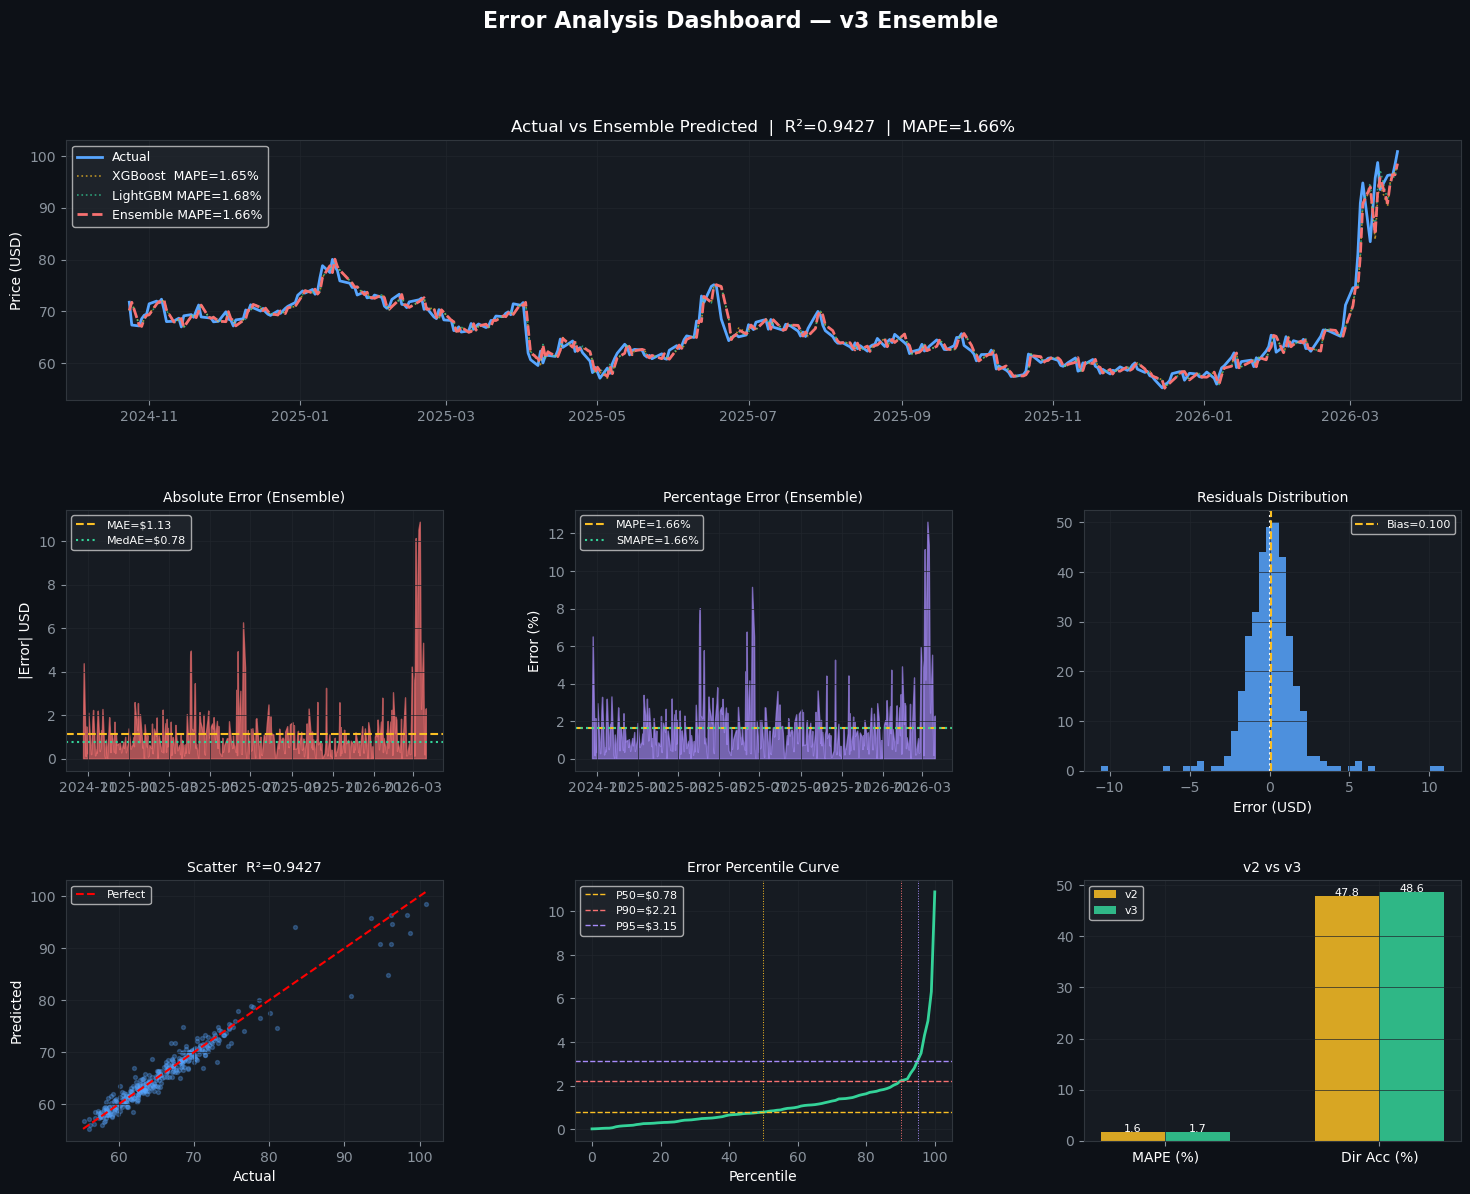

In [12]:
me = m_ens   

fig = plt.figure(figsize=(18, 13), facecolor=DARK)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle('Error Analysis Dashboard — v3 Ensemble',
             color='white', fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(gs[0, :])
sax(ax1)
ax1.plot(test_dates, actual_price,   color=BLUE,   lw=2,   label='Actual')
ax1.plot(test_dates, xgb_price,      color=YELLOW, lw=1.2, linestyle=':', alpha=0.7,  label=f'XGBoost  MAPE={m_xgb["MAPE"]:.2f}%')
ax1.plot(test_dates, lgbm_price,     color=GREEN,  lw=1.2, linestyle=':', alpha=0.7,  label=f'LightGBM MAPE={m_lgbm["MAPE"]:.2f}%')
ax1.plot(test_dates, ensemble_price, color=RED,    lw=2,   linestyle='--',            label=f'Ensemble MAPE={m_ens["MAPE"]:.2f}%')
ax1.set_title(f'Actual vs Ensemble Predicted  |  R²={m_ens["R2"]:.4f}  |  MAPE={m_ens["MAPE"]:.2f}%',
              color='white', fontsize=12)
ax1.set_ylabel('Price (USD)', color='white')
ax1.legend(facecolor='#21262d', labelcolor='white', fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
sax(ax2)
ax2.fill_between(test_dates, me['abs_err'], alpha=0.65, color=RED)
ax2.axhline(me['MAE'],   color=YELLOW, linestyle='--', lw=1.5, label=f'MAE=${me["MAE"]:.2f}')
ax2.axhline(me['MedAE'], color=GREEN,  linestyle=':',  lw=1.5, label=f'MedAE=${me["MedAE"]:.2f}')
ax2.set_title('Absolute Error (Ensemble)', color='white', fontsize=10)
ax2.set_ylabel('|Error| USD', color='white')
ax2.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
sax(ax3)
ax3.fill_between(test_dates, me['pct_err'], alpha=0.65, color=PURPLE)
ax3.axhline(me['MAPE'],  color=YELLOW, linestyle='--', lw=1.5, label=f'MAPE={me["MAPE"]:.2f}%')
ax3.axhline(me['SMAPE'], color=GREEN,  linestyle=':',  lw=1.5, label=f'SMAPE={me["SMAPE"]:.2f}%')
ax3.set_title('Percentage Error (Ensemble)', color='white', fontsize=10)
ax3.set_ylabel('Error (%)', color='white')
ax3.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

ax4 = fig.add_subplot(gs[1, 2])
sax(ax4)
ax4.hist(me['errors'], bins=50, color=BLUE, alpha=0.85, edgecolor='none')
ax4.axvline(0, color='white', linestyle=':', lw=1.5)
ax4.axvline(me['errors'].mean(), color=YELLOW, linestyle='--', lw=1.5,
            label=f'Bias={me["errors"].mean():.3f}')
ax4.set_title('Residuals Distribution', color='white', fontsize=10)
ax4.set_xlabel('Error (USD)', color='white')
ax4.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

ax5 = fig.add_subplot(gs[2, 0])
sax(ax5)
ax5.scatter(actual_price, ensemble_price, alpha=0.3, s=8, color=BLUE)
lm = [min(actual_price.min(), ensemble_price.min()),
      max(actual_price.max(), ensemble_price.max())]
ax5.plot(lm, lm, 'r--', lw=1.5, label='Perfect')
ax5.set_xlabel('Actual', color='white')
ax5.set_ylabel('Predicted', color='white')
ax5.set_title(f'Scatter  R²={m_ens["R2"]:.4f}', color='white', fontsize=10)
ax5.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

ax6 = fig.add_subplot(gs[2, 1])
sax(ax6)
pts = np.arange(0, 101)
ax6.plot(pts, np.percentile(me['abs_err'], pts), color=GREEN, lw=2)
for p, col in [(50,YELLOW),(90,RED),(95,PURPLE)]:
    v = np.percentile(me['abs_err'], p)
    ax6.axhline(v, color=col, linestyle='--', lw=1, label=f'P{p}=${v:.2f}')
    ax6.axvline(p, color=col, linestyle=':', lw=0.7)
ax6.set_title('Error Percentile Curve', color='white', fontsize=10)
ax6.set_xlabel('Percentile', color='white')
ax6.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

ax7 = fig.add_subplot(gs[2, 2])
sax(ax7)
cats = ['MAPE (%)', 'Dir Acc (%)']
v2_  = [1.6467, 47.81]
v3_  = [m_ens['MAPE'], clf_acc]
xp   = np.arange(len(cats))
w    = 0.3
ax7.bar(xp-w/2, v2_, w, color=YELLOW, alpha=0.85, label='v2')
ax7.bar(xp+w/2, v3_, w, color=GREEN,  alpha=0.85, label='v3')
for i,(a,b) in enumerate(zip(v2_,v3_)):
    ax7.text(i-w/2, a+0.2, f'{a:.1f}', ha='center', color='white', fontsize=8)
    ax7.text(i+w/2, b+0.2, f'{b:.1f}', ha='center', color='white', fontsize=8)
ax7.set_xticks(xp)
ax7.set_xticklabels(cats, color='white')
ax7.set_title('v2 vs v3', color='white', fontsize=10)
ax7.legend(facecolor='#21262d', labelcolor='white', fontsize=8)

plt.show()

In [13]:
abs_e = me['abs_err']
errs  = me['errors']

tbl = pd.DataFrame({
    'Metric': ['MAE','MSE','RMSE','MedAE','Max Error',
               'MAPE (%)','SMAPE (%)','RMSPE (%)',
               'R²','Adjusted R²',
               'Bias (Mean Error)','Error Std Dev',
               'P50 |Error|','P75 |Error|','P90 |Error|','P95 |Error|','P99 |Error|',
               'Direction Acc (regressor)',
               'Direction Acc (classifier)',
               'Over-predictions','Under-predictions'],
    'Ensemble Value': [
        f'${me["MAE"]:.4f}', f'{me["MSE"]:.4f}', f'${me["RMSE"]:.4f}',
        f'${me["MedAE"]:.4f}', f'${me["MaxErr"]:.4f}',
        f'{me["MAPE"]:.4f}%', f'{me["SMAPE"]:.4f}%', f'{me["RMSPE"]:.4f}%',
        f'{me["R2"]:.6f}', f'{me["R2adj"]:.6f}',
        f'{errs.mean():+.4f}', f'{errs.std():.4f}',
        f'${np.percentile(abs_e,50):.4f}',
        f'${np.percentile(abs_e,75):.4f}',
        f'${np.percentile(abs_e,90):.4f}',
        f'${np.percentile(abs_e,95):.4f}',
        f'${np.percentile(abs_e,99):.4f}',
        f'{me["Dir"]:.2f}%',
        f'{clf_acc:.2f}%',
        f'{(errs<0).sum()} ({(errs<0).mean()*100:.1f}%)',
        f'{(errs>0).sum()} ({(errs>0).mean()*100:.1f}%)',
    ]
})
print(tbl.to_string(index=False))

                    Metric Ensemble Value
                       MAE        $1.1318
                       MSE         3.0624
                      RMSE        $1.7500
                     MedAE        $0.7783
                 Max Error       $10.8959
                  MAPE (%)        1.6584%
                 SMAPE (%)        1.6602%
                 RMSPE (%)        2.3767%
                        R²       0.942671
               Adjusted R²       0.927876
         Bias (Mean Error)        +0.1000
             Error Std Dev         1.7471
               P50 |Error|        $0.7783
               P75 |Error|        $1.4256
               P90 |Error|        $2.2146
               P95 |Error|        $3.1460
               P99 |Error|        $6.3101
 Direction Acc (regressor)         47.73%
Direction Acc (classifier)         48.58%
          Over-predictions    176 (50.0%)
         Under-predictions    176 (50.0%)


Computing SHAP values (this takes ~30s)...


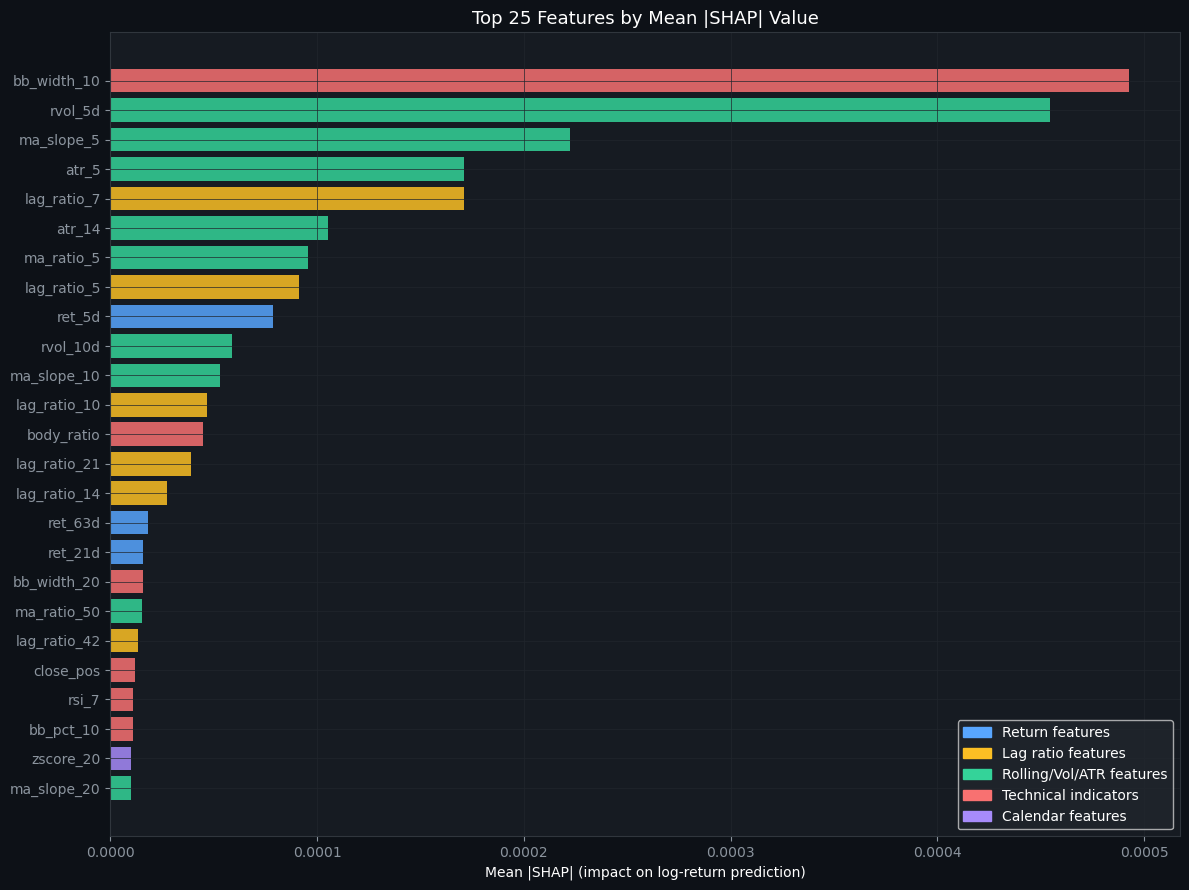


Top 10 features by SHAP:
    Feature     SHAP
bb_width_10 0.000493
    rvol_5d 0.000454
 ma_slope_5 0.000222
      atr_5 0.000171
lag_ratio_7 0.000171
     atr_14 0.000105
 ma_ratio_5 0.000095
lag_ratio_5 0.000091
     ret_5d 0.000079
   rvol_10d 0.000059


In [14]:
print('Computing SHAP values (this takes ~30s)...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_s)

shap_df = (pd.DataFrame({'Feature': FEATURE_COLS,
                          'SHAP': np.abs(shap_values).mean(axis=0)})
            .sort_values('SHAP', ascending=False).head(25).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 9), facecolor=DARK)
sax(ax)

def fc(n):
    if any(x in n for x in ['ret','log']): return BLUE
    if 'lag' in n:                          return YELLOW
    if any(x in n for x in ['ma','std','vol','rvol','atr']): return GREEN
    if any(x in n for x in ['rsi','macd','bb','stoch','will','mom','hl','close_p','body','wick']): return RED
    return PURPLE

ax.barh(shap_df['Feature'][::-1], shap_df['SHAP'][::-1],
        color=[fc(f) for f in shap_df['Feature'][::-1]], alpha=0.85)
ax.set_title('Top 25 Features by Mean |SHAP| Value', color='white', fontsize=13)
ax.set_xlabel('Mean |SHAP| (impact on log-return prediction)', color='white')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=BLUE,   label='Return features'),
    Patch(color=YELLOW, label='Lag ratio features'),
    Patch(color=GREEN,  label='Rolling/Vol/ATR features'),
    Patch(color=RED,    label='Technical indicators'),
    Patch(color=PURPLE, label='Calendar features'),
], facecolor='#21262d', labelcolor='white', loc='lower right')
plt.tight_layout()
plt.show()

print('\nTop 10 features by SHAP:')
print(shap_df.head(10).to_string(index=False))

In [15]:
X_all  = feat_df[FEATURE_COLS].values
yr_all = feat_df['target_log_ret'].values
yp_all = feat_df['target_price'].values
cn_all = feat_df['Close'].values

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_sc = RobustScaler()
cv_records = []

print(f'Purged Walk-Forward CV (gap={GAP} days)')
print('-' * 72)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_all), 1):
    tr_idx_purged = tr_idx[:-GAP] if len(tr_idx) > GAP else tr_idx

    Xtr_s  = cv_sc.fit_transform(X_all[tr_idx_purged])
    Xv_s   = cv_sc.transform(X_all[val_idx])
    ytr    = yr_all[tr_idx_purged]
    yv_lr  = yr_all[val_idx]
    yv_p   = yp_all[val_idx]
    cv_c   = cn_all[val_idx]

    xm = XGBRegressor(**best_xgb_params)
    xm.fit(Xtr_s, ytr, verbose=False)
    lm_ = LGBMRegressor(**best_lgbm_params)
    lm_.fit(Xtr_s, ytr)

    plr_x = xm.predict(Xv_s)
    plr_l = lm_.predict(Xv_s)
    plr   = w_xgb * plr_x + w_lgbm * plr_l
    pp    = cv_c * np.exp(plr)

    mae_  = mean_absolute_error(yv_p, pp)
    rmse_ = np.sqrt(mean_squared_error(yv_p, pp))
    mape_ = np.mean(np.abs(yv_p-pp)/(np.abs(yv_p)+1e-9))*100
    r2_   = r2_score(yv_p, pp)
    dir_  = (np.sign(plr)==np.sign(yv_lr)).mean()*100

    cv_records.append({'Fold':fold,'Train':len(tr_idx_purged),
                       'Val':len(val_idx),
                       'MAE':round(mae_,3),'RMSE':round(rmse_,3),
                       'MAPE(%)':round(mape_,3),'R2':round(r2_,4),'Dir%':round(dir_,1)})
    print(f'  Fold {fold} | Train={len(tr_idx_purged):4d} Val={len(val_idx):3d} | '
          f'MAE=${mae_:.2f} MAPE={mape_:.2f}% R²={r2_:.4f} Dir={dir_:.1f}%')

cv_df = pd.DataFrame(cv_records)
print('-' * 72)
print(f'  Mean: MAE=${cv_df["MAE"].mean():.3f}±{cv_df["MAE"].std():.3f} | '
      f'MAPE={cv_df["MAPE(%)"].mean():.3f}%±{cv_df["MAPE(%)"].std():.3f}% | '
      f'R²={cv_df["R2"].mean():.4f}±{cv_df["R2"].std():.4f} | '
      f'Dir={cv_df["Dir%"].mean():.1f}%')

Purged Walk-Forward CV (gap=5 days)
------------------------------------------------------------------------
  Fold 1 | Train= 390 Val=390 | MAE=$0.91 MAPE=1.53% R²=0.9700 Dir=54.1%
  Fold 2 | Train= 780 Val=390 | MAE=$0.92 MAPE=2.13% R²=0.9886 Dir=53.6%
  Fold 3 | Train=1170 Val=390 | MAE=$1.90 MAPE=2.13% R²=0.9649 Dir=55.1%
  Fold 4 | Train=1560 Val=390 | MAE=$1.21 MAPE=1.57% R²=0.9198 Dir=50.5%
  Fold 5 | Train=1950 Val=390 | MAE=$1.16 MAPE=1.69% R²=0.9398 Dir=49.7%
------------------------------------------------------------------------
  Mean: MAE=$1.219±0.405 | MAPE=1.808%±0.299% | R²=0.9566±0.0270 | Dir=52.6%


In [16]:
def forecast_ensemble(xgb_m, lgbm_m, dir_m, scaler,
                       feat_df, feature_cols, w_x, w_l, steps=30):
    extended  = feat_df.copy()
    last_date = extended.index[-1]
    fut_dates, fut_prices, fut_lrs, fut_dirs, fut_probs = [], [], [], [], []

    for step in range(steps):
        row  = extended[feature_cols].iloc[[-1]].values
        rs   = scaler.transform(row)
        plr  = w_x * float(xgb_m.predict(rs)[0]) + w_l * float(lgbm_m.predict(rs)[0])
        pc   = float(extended['Close'].iloc[-1])
        pp   = pc * np.exp(plr)
        dp   = float(dir_m.predict_proba(rs)[0, 1]) 
        dd   = int(dp >= 0.5)

        next_date = last_date + pd.tseries.offsets.BDay(step + 1)
        fut_dates.append(next_date)
        fut_prices.append(round(pp, 2))
        fut_lrs.append(plr)
        fut_dirs.append(dd)
        fut_probs.append(round(dp, 4))

        new_row = extended.iloc[[-1]].copy()
        new_row.index = [next_date]
        new_row['Close'] = pp
        new_row['Open']  = pp
        new_row['High']  = pp
        new_row['Low']   = pp

        for p in [1,2,3,5,10,21,63]:
            rc = f'ret_{p}d'
            if rc in extended.columns and len(extended) >= p:
                new_row[rc] = pp / extended['Close'].iloc[-p] - 1

        extended = pd.concat([extended, new_row])

    return pd.DataFrame({
        'Date': fut_dates, 'Forecast': fut_prices,
        'LogRet': fut_lrs, 'Direction': fut_dirs,
        'UpProb': fut_probs
    }).set_index('Date')


print(f'Forecasting {MULTI_STEP_DAYS} business days...')
future_df    = forecast_ensemble(
    xgb_model, lgbm_model, dir_clf, scaler,
    feat_df, FEATURE_COLS, w_xgb, w_lgbm, MULTI_STEP_DAYS
)

latest_price = float(df['Close'].iloc[-1])
final_price  = future_df['Forecast'].iloc[-1]
chg_pct      = (final_price - latest_price) / latest_price * 100
up_days      = future_df['Direction'].sum()
print(f'Current: ${latest_price:.2f}  |  30-Day Forecast: ${final_price:.2f}  ({chg_pct:+.2f}%)')
print(f'Predicted up days: {up_days}/30  |  down days: {30-up_days}/30')

Forecasting 30 business days...
Current: $100.82  |  30-Day Forecast: $106.16  (+5.30%)
Predicted up days: 0/30  |  down days: 30/30


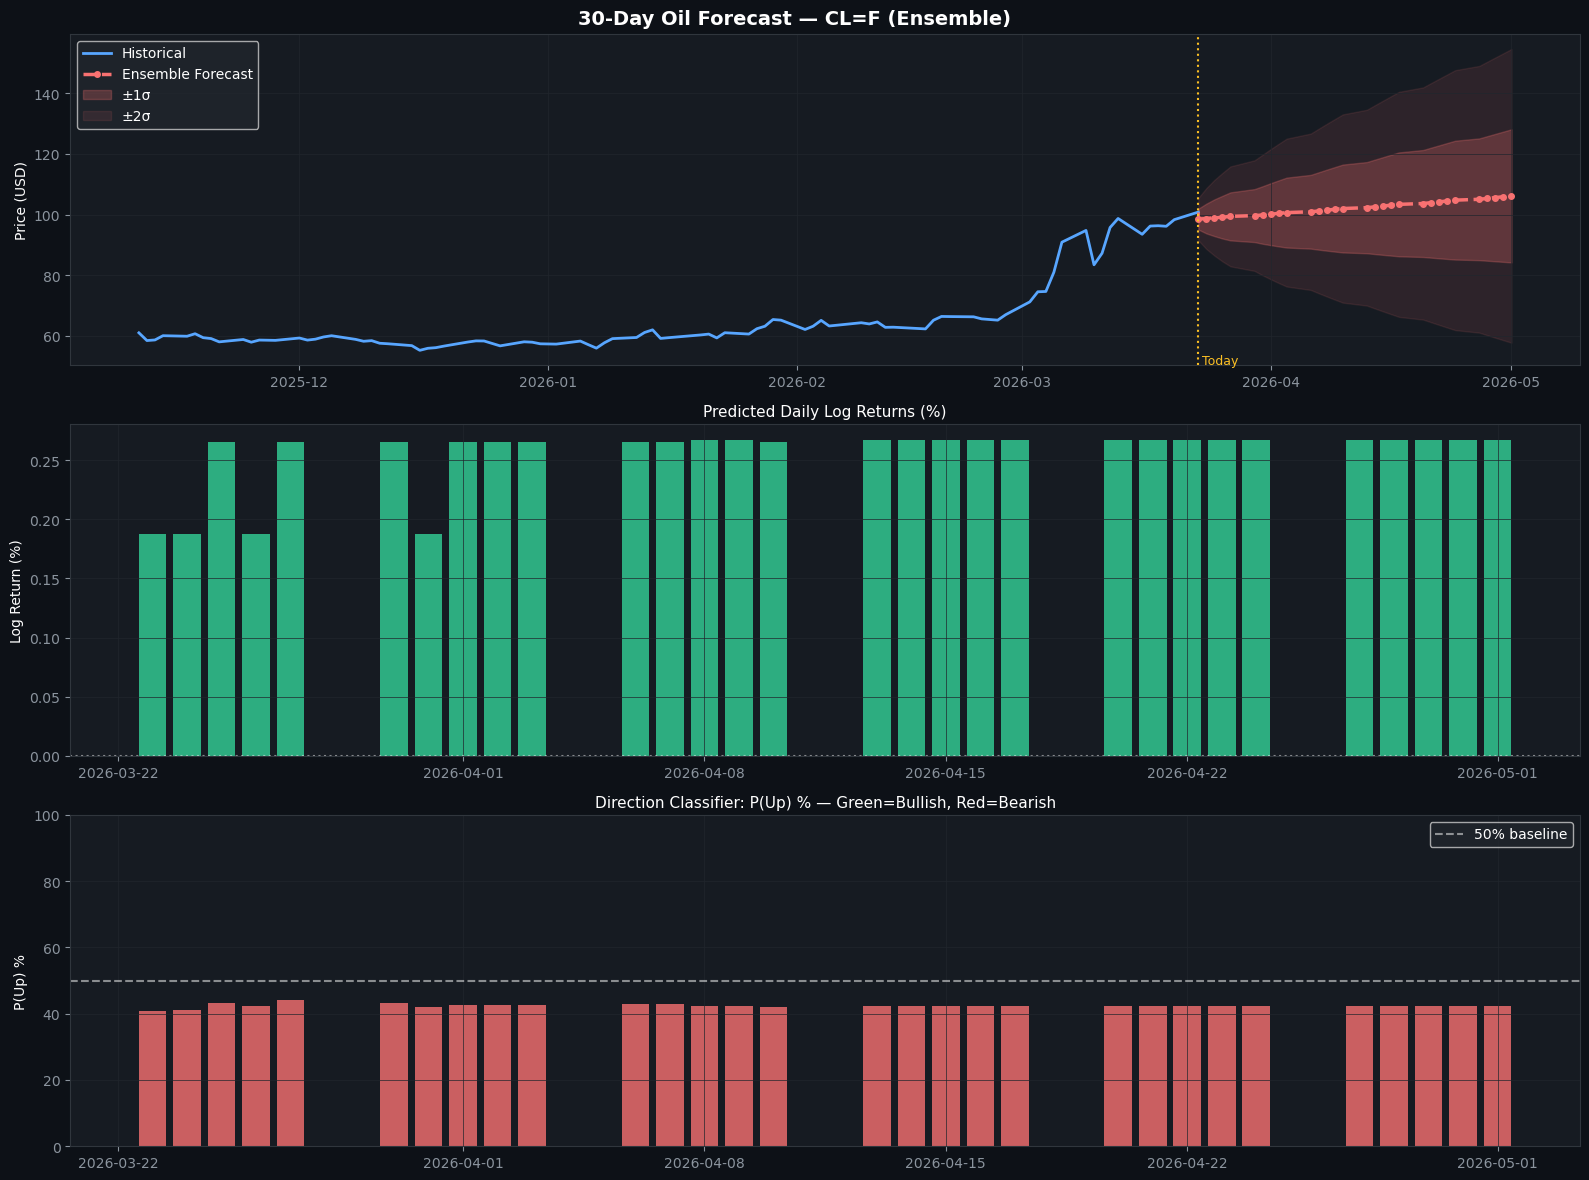

            Forecast vs Today (%)  Daily Ret (%)  Signal  P(Up) %
Date                                                             
2026-03-23     98.50        -2.3%          0.187  🔴 Down     40.9
2026-03-24     98.69       -2.11%          0.187  🔴 Down     41.1
2026-03-25     98.95       -1.85%          0.265  🔴 Down     43.2
2026-03-26     99.14       -1.67%          0.187  🔴 Down     42.5
2026-03-27     99.40       -1.41%          0.265  🔴 Down     44.1
2026-03-30     99.66       -1.15%          0.265  🔴 Down     43.3
2026-03-31     99.85       -0.96%          0.187  🔴 Down     42.1
2026-04-01    100.12       -0.69%          0.265  🔴 Down     42.8
2026-04-02    100.38       -0.44%          0.265  🔴 Down     42.8
2026-04-03    100.65       -0.17%          0.265  🔴 Down     42.8
2026-04-06    100.92         0.1%          0.265  🔴 Down     43.1
2026-04-07    101.18        0.36%          0.265  🔴 Down     43.1
2026-04-08    101.45        0.62%          0.267  🔴 Down     42.2
2026-04-09

In [17]:
history_90 = df['Close'].iloc[-90:]
daily_vol  = float(feat_df['rvol_5d'].iloc[-1]) / np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor=DARK)
fig.suptitle(f'30-Day Oil Forecast — {TICKER} (Ensemble)',
             color='white', fontsize=14, fontweight='bold')

ax = axes[0]
sax(ax)
ax.plot(history_90.index, history_90.values, color=BLUE, lw=2, label='Historical')
ax.plot([history_90.index[-1], future_df.index[0]],
        [history_90.iloc[-1], future_df['Forecast'].iloc[0]],
        color=RED, lw=2, linestyle='--')
ax.plot(future_df.index, future_df['Forecast'],
        color=RED, lw=2.5, linestyle='--', marker='o', markersize=4,
        label='Ensemble Forecast')

horizons = np.arange(1, MULTI_STEP_DAYS+1)
for sig, alp, lb in [(1, 0.25, '±1σ'),(2, 0.10, '±2σ')]:
    bw = future_df['Forecast'].values * (np.exp(sig*daily_vol*np.sqrt(horizons))-1)
    ax.fill_between(future_df.index,
                    future_df['Forecast'].values+bw,
                    future_df['Forecast'].values-bw,
                    alpha=alp, color=RED, label=lb)

ax.axvline(history_90.index[-1], color=YELLOW, linestyle=':', lw=1.5)
ax.text(history_90.index[-1], ax.get_ylim()[0]*1.01, ' Today', color=YELLOW, fontsize=9)
ax.set_ylabel('Price (USD)', color='white')
ax.legend(facecolor='#21262d', labelcolor='white')

ax2 = axes[1]
sax(ax2)
brc = [GREEN if v >= 0 else RED for v in future_df['LogRet']]
ax2.bar(future_df.index, future_df['LogRet']*100, color=brc, alpha=0.8, width=0.8)
ax2.axhline(0, color='white', linestyle=':', alpha=0.5)
ax2.set_title('Predicted Daily Log Returns (%)', color='white', fontsize=11)
ax2.set_ylabel('Log Return (%)', color='white')

ax3 = axes[2]
sax(ax3)
bar_c = [GREEN if p >= 0.5 else RED for p in future_df['UpProb']]
bars  = ax3.bar(future_df.index, future_df['UpProb']*100, color=bar_c, alpha=0.8, width=0.8)
ax3.axhline(50, color='white', linestyle='--', alpha=0.5, label='50% baseline')
ax3.set_title('Direction Classifier: P(Up) % — Green=Bullish, Red=Bearish',
              color='white', fontsize=11)
ax3.set_ylabel('P(Up) %', color='white')
ax3.set_ylim(0, 100)
ax3.legend(facecolor='#21262d', labelcolor='white')

plt.tight_layout()
plt.show()

fdf = future_df.copy()
fdf.index = fdf.index.strftime('%Y-%m-%d')
fdf['vs Today (%)'] = ((fdf['Forecast']-latest_price)/latest_price*100).round(2).astype(str)+'%'
fdf['Daily Ret (%)']= (fdf['LogRet']*100).round(3)
fdf['Signal']       = fdf['Direction'].map({1:'🟢 Up','0':'🔴 Down', 0:'🔴 Down'})
fdf['P(Up) %']      = (fdf['UpProb']*100).round(1)
fdf.drop(columns=['LogRet','Direction','UpProb'], inplace=True)
print(fdf.to_string())

In [18]:
print('   OIL PRICE FORECASTING v3 — FINAL SUMMARY')
print(f'  Ticker         : {TICKER}  ({PERIOD}, {len(df):,} rows)')
print(f'  Features       : {len(FEATURE_COLS)}')
print(f'  Models         : XGBoost + LightGBM ensemble + Direction clf')
print(f'  Optuna Trials  : {OPTUNA_TRIALS} per model')
print(f'  Weights        : XGB={w_xgb:.3f}  LGBM={w_lgbm:.3f}')
print()
print('  ENSEMBLE TEST SET PERFORMANCE:')
print(f'    MAE          : ${me["MAE"]:.4f}')
print(f'    MSE          : {me["MSE"]:.4f}')
print(f'    RMSE         : ${me["RMSE"]:.4f}')
print(f'    MedAE        : ${me["MedAE"]:.4f}')
print(f'    Max Error    : ${me["MaxErr"]:.4f}')
print(f'    MAPE         : {me["MAPE"]:.4f}%')
print(f'    SMAPE        : {me["SMAPE"]:.4f}%')
print(f'    RMSPE        : {me["RMSPE"]:.4f}%')
print(f'    R²           : {me["R2"]:.6f}')
print(f'    Adj R²       : {me["R2adj"]:.6f}')
print(f'    Dir% (clf)   : {clf_acc:.2f}%')
print()
print('  CV (Purged Walk-Forward, 5-Fold):')
print(f'    MAE    : {cv_df["MAE"].mean():.3f}±{cv_df["MAE"].std():.3f}')
print(f'    MAPE   : {cv_df["MAPE(%)"].mean():.3f}%±{cv_df["MAPE(%)"].std():.3f}%')
print(f'    R²     : {cv_df["R2"].mean():.4f}±{cv_df["R2"].std():.4f}')
print(f'    Dir%   : {cv_df["Dir%"].mean():.1f}%')
print()
print('  IMPROVEMENT TIMELINE:')
print(f'    v1  MAPE=13.15%   R²=-1.2605  Dir%=~50%')
print(f'    v2  MAPE= 1.65%   R²= 0.9270  Dir%=47.8%')
print(f'    v3  MAPE={me["MAPE"]:5.2f}%   R²= {me["R2"]:.4f}  Dir%={clf_acc:.1f}%')
print()
print('  FORECAST:')
print(f'    Current: ${latest_price:.2f}  30-Day: ${final_price:.2f}  ({chg_pct:+.2f}%)')
print(f'    Up days: {up_days}/30  Down days: {30-up_days}/30')

   OIL PRICE FORECASTING v3 — FINAL SUMMARY
  Ticker         : CL=F  (10y, 2,514 rows)
  Features       : 72
  Models         : XGBoost + LightGBM ensemble + Direction clf
  Optuna Trials  : 80 per model
  Weights        : XGB=0.501  LGBM=0.499

  ENSEMBLE TEST SET PERFORMANCE:
    MAE          : $1.1318
    MSE          : 3.0624
    RMSE         : $1.7500
    MedAE        : $0.7783
    Max Error    : $10.8959
    MAPE         : 1.6584%
    SMAPE        : 1.6602%
    RMSPE        : 2.3767%
    R²           : 0.942671
    Adj R²       : 0.927876
    Dir% (clf)   : 48.58%

  CV (Purged Walk-Forward, 5-Fold):
    MAE    : 1.219±0.405
    MAPE   : 1.808%±0.299%
    R²     : 0.9566±0.0270
    Dir%   : 52.6%

  IMPROVEMENT TIMELINE:
    v1  MAPE=13.15%   R²=-1.2605  Dir%=~50%
    v2  MAPE= 1.65%   R²= 0.9270  Dir%=47.8%
    v3  MAPE= 1.66%   R²= 0.9427  Dir%=48.6%

  FORECAST:
    Current: $100.82  30-Day: $106.16  (+5.30%)
    Up days: 0/30  Down days: 30/30
